# Regularized Linear Regression. Practical Assignment

## Objective

The objective of this project was to learn how to build a linear regression model with regularization using real-world data.

## Project Tasks

During this project, I:

1. Loaded the data and explored its structure.
2. Analyzed the data and created new features.
3. Split the data into training and test sets.
4. Built a linear regression model using the Scikit-learn library.
5. Selected appropriate regularization coefficients.
6. Evaluated the model using MSE, MAE, and $R^2$ metrics.
7. Answered the questions at the end of the notebook.

## Evaluation Criteria

During the project, I focused on:

* completing all stages of the task;
* selecting appropriate regularization coefficients;
* drawing conclusions based on the results;
* checking that the model did not overfit;
* obtaining a model with good performance;
* drawing final conclusions based on the results.

## Dataset

I worked with a dataset containing house sales data. The dataset includes a larger number of features compared to the previous module.

### Feature Description

* **LotArea** — lot size in square feet.
* **LotArea_M** — lot size in square meters.
* **Street** — type of road access.
* **BldgType** — type of dwelling.
* **OverallQual** — overall material and finish quality.
* **OverallCond** — overall condition of the property.
* **YearBuilt** — original construction year.
* **YearRemodAdd** — year of remodeling.
* **RoofStyle** — type of roof.
* **ExterQual** — exterior material quality.
* **ExterCond** — current condition of exterior materials.
* **Foundation** — type of foundation.
* **TotalBsmtSF** — total basement area in square feet.
* **TotalBsmtSF_M** — total basement area in square meters.
* **Heating** — type of heating system.
* **HeatingQC** — heating quality and condition.
* **CentralAir** — air conditioning.
* **GrLivArea** — above-ground living area in square feet.
* **GrLivArea_M** — above-ground living area in square meters.
* **Bath** — number of bathrooms.
* **KitchenQual** — kitchen quality.
* **GarageArea** — garage area in square feet.
* **GarageArea_M** — garage area in square meters.
* **DateSold** — month and year of sale.
* **SaleCondition** — sale conditions.
* **SalePrice** — sale price in USD. This is the target variable I aimed to predict.

## Model

I built a linear regression model using this dataset and evaluated its performance on both the training and test sets.

I used **MAE**, **MSE**, and **$R^2$** to evaluate the model and compared the results between the training and test sets to determine whether the model was overfitted.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
df = pd.read_csv('data/data.csv')
df.head()

,LotArea,LotArea_M,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,...,CentralAir,GrLivArea,GrLivArea_M,Bath,KitchenQual,GarageArea,GarageArea_M,DateSold,SaleCondition,SalePrice
0,8450,785.03035,Pave,1Fam,7,5,2003,2003,Gable,Gd,...,Y,1710,158.864130,3,Gd,548,50.910844,2/2008,Normal,208500
1,9600,891.86880,Pave,1Fam,6,8,1976,1976,Gable,TA,...,Y,1262,117.243586,2,TA,460,42.735380,5/2007,Normal,181500
2,11250,1045.15875,Pave,1Fam,7,5,2001,2002,Gable,Gd,...,Y,1786,165.924758,3,Gd,608,56.485024,9/2008,Normal,223500
3,9550,887.22365,Pave,1Fam,7,5,1915,1970,Gable,TA,...,Y,1717,159.514451,1,Gd,642,59.643726,2/2006,Abnorml,140000
4,14260,1324.79678,Pave,1Fam,8,5,2000,2000,Gable,Gd,...,Y,2198,204.200794,3,Gd,836,77.666908,12/2008,Normal,250000


## Exploratory Data Analysis (EDA)

In [41]:
df.describe()

,LotArea,LotArea_M,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,TotalBsmtSF_M,GrLivArea,GrLivArea_M,Bath,GarageArea,GarageArea_M,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,977.044879,6.099315,5.575342,1971.267808,1984.865753,1057.429452,98.238368,1515.463699,140.791124,1.947945,472.980137,43.941274,180921.195890
std,9981.264932,927.289456,1.382997,1.112799,30.202904,20.645407,438.705324,40.757041,525.480383,48.818704,0.794965,213.804841,19.863111,79442.502883
min,1300.000000,120.773900,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,334.000000,31.029602,0.000000,0.000000,0.000000,34900.000000
25%,7553.500000,701.742811,5.000000,5.000000,1954.000000,1967.000000,795.750000,73.927562,1129.500000,104.933938,1.000000,334.500000,31.076054,129975.000000
50%,9478.500000,880.581085,6.000000,5.000000,1973.000000,1994.000000,991.500000,92.113325,1464.000000,136.009992,2.000000,480.000000,44.593440,163000.000000
75%,11601.500000,1077.814155,7.000000,6.000000,2000.000000,2004.000000,1298.250000,120.611320,1776.750000,165.065405,3.000000,576.000000,53.512128,214000.000000
max,215245.000000,19996.906235,10.000000,9.000000,2010.000000,2010.000000,6110.000000,567.637330,5642.000000,524.158726,4.000000,1418.000000,131.736454,755000.000000


## A correlation matrix of the numerical features was created. Linearly dependent features were removed from the dataset.

In [42]:
df.select_dtypes(include='number').corr()

,LotArea,LotArea_M,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,TotalBsmtSF_M,GrLivArea,GrLivArea_M,Bath,GarageArea,GarageArea_M,SalePrice
LotArea,1.000000,1.000000,0.105806,-0.005636,0.014228,0.013788,0.260833,0.260833,0.263116,0.263116,0.096360,0.180403,0.180403,0.263843
LotArea_M,1.000000,1.000000,0.105806,-0.005636,0.014228,0.013788,0.260833,0.260833,0.263116,0.263116,0.096360,0.180403,0.180403,0.263843
OverallQual,0.105806,0.105806,1.000000,-0.091932,0.572323,0.550684,0.537808,0.537808,0.593007,0.593007,0.554555,0.562022,0.562022,0.790982
OverallCond,-0.005636,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.171098,-0.171098,-0.079686,-0.079686,-0.172989,-0.151521,-0.151521,-0.077856
YearBuilt,0.014228,0.014228,0.572323,-0.375983,1.000000,0.592855,0.391452,0.391452,0.199010,0.199010,0.478016,0.478954,0.478954,0.522897
YearRemodAdd,0.013788,0.013788,0.550684,0.073741,0.592855,1.000000,0.291066,0.291066,0.287389,0.287389,0.420235,0.371600,0.371600,0.507101
TotalBsmtSF,0.260833,0.260833,0.537808,-0.171098,0.391452,0.291066,1.000000,1.000000,0.454868,0.454868,0.193469,0.486665,0.486665,0.613581
TotalBsmtSF_M,0.260833,0.260833,0.537808,-0.171098,0.391452,0.291066,1.000000,1.000000,0.454868,0.454868,0.193469,0.486665,0.486665,0.613581
GrLivArea,0.263116,0.263116,0.593007,-0.079686,0.199010,0.287389,0.454868,0.454868,1.000000,1.000000,0.699614,0.468997,0.468997,0.708624
GrLivArea_M,0.263116,0.263116,0.593007,-0.079686,0.199010,0.287389,0.454868,0.454868,1.000000,1.000000,0.699614,0.468997,0.468997,0.708624


In [43]:
df = df.drop(columns = ['LotArea_M', 'TotalBsmtSF_M', 'GrLivArea_M', 'GarageArea_M'])

In [44]:
df.head()

,LotArea,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,ExterCond,...,Heating,HeatingQC,CentralAir,GrLivArea,Bath,KitchenQual,GarageArea,DateSold,SaleCondition,SalePrice
0,8450,Pave,1Fam,7,5,2003,2003,Gable,Gd,TA,...,GasA,Ex,Y,1710,3,Gd,548,2/2008,Normal,208500
1,9600,Pave,1Fam,6,8,1976,1976,Gable,TA,TA,...,GasA,Ex,Y,1262,2,TA,460,5/2007,Normal,181500
2,11250,Pave,1Fam,7,5,2001,2002,Gable,Gd,TA,...,GasA,Ex,Y,1786,3,Gd,608,9/2008,Normal,223500
3,9550,Pave,1Fam,7,5,1915,1970,Gable,TA,TA,...,GasA,Gd,Y,1717,1,Gd,642,2/2006,Abnorml,140000
4,14260,Pave,1Fam,8,5,2000,2000,Gable,Gd,TA,...,GasA,Ex,Y,2198,3,Gd,836,12/2008,Normal,250000


## Individual plots showing the relationship between the target variable and each individual feature were created.

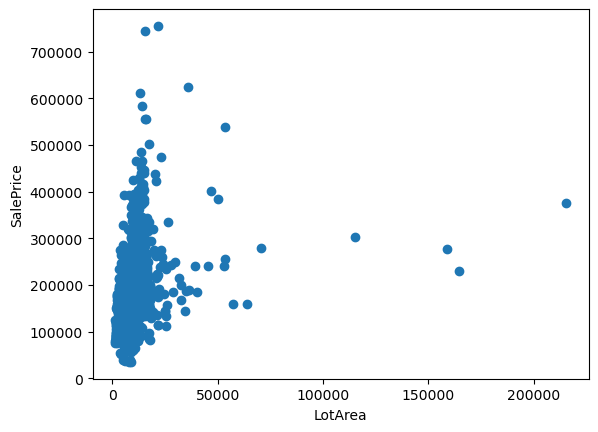

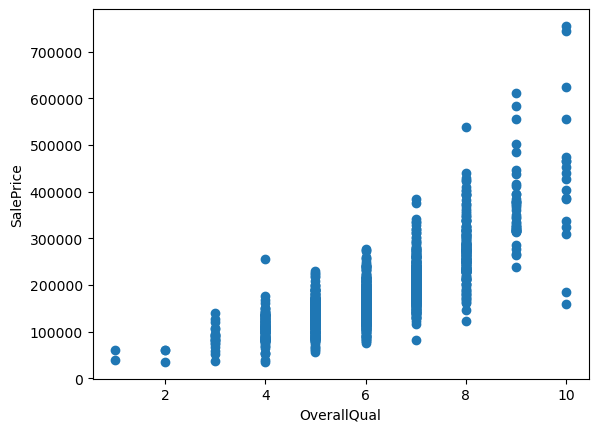

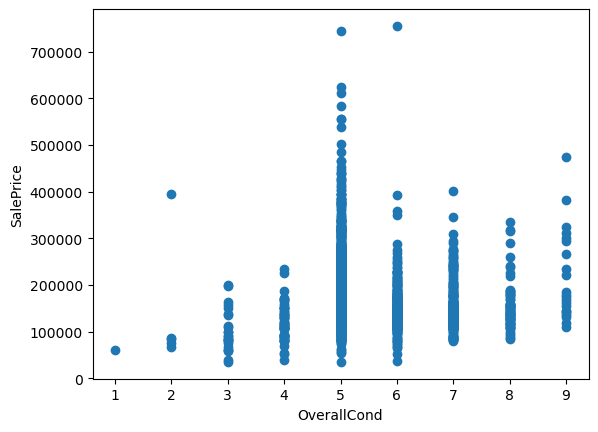

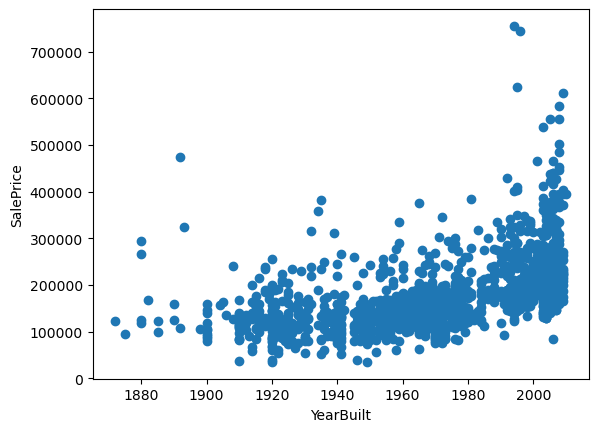

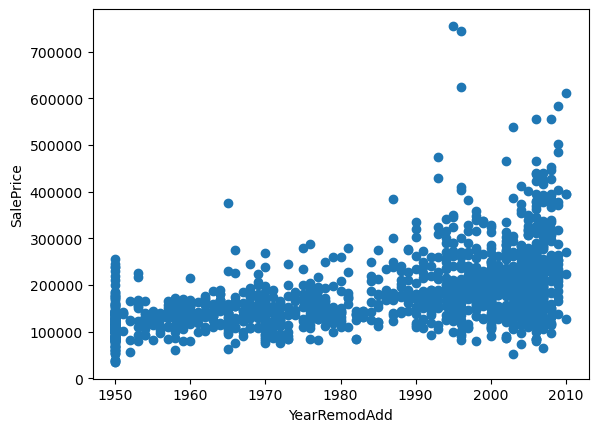

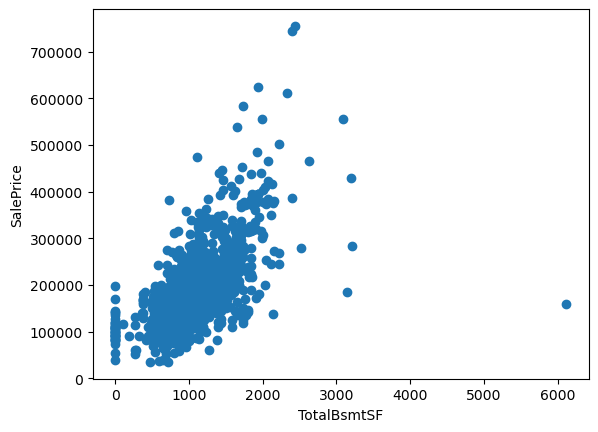

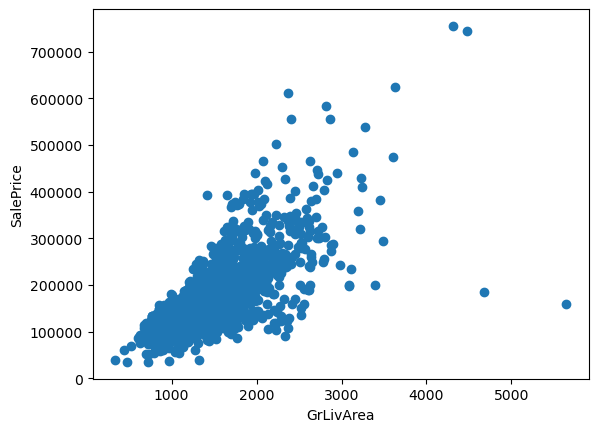

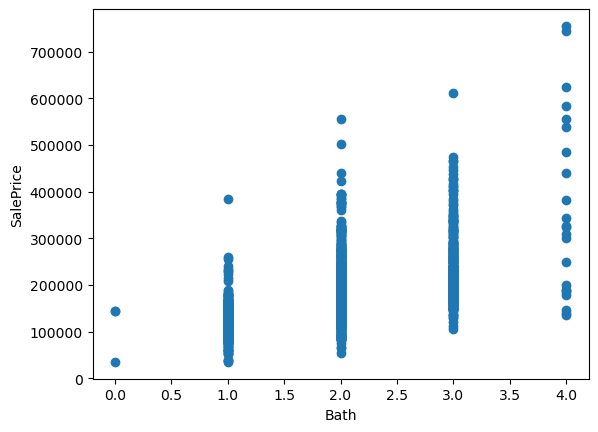

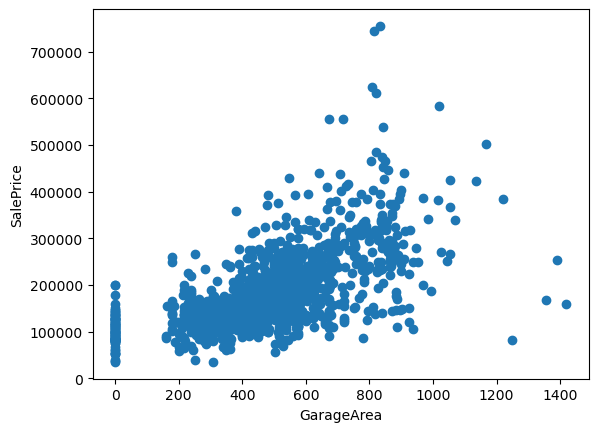

In [45]:
numeric_columns = df.select_dtypes(include='number')

for column in numeric_columns:
    if column != 'SalePrice':
        plt.scatter(df[column], df['SalePrice'])
        plt.xlabel(column)
        plt.ylabel('SalePrice')
        plt.show()

Based on the individual plots showing the relationship between the target variable `SalePrice` and individual numerical features, the following conclusions can be drawn:

1. A **weak positive relationship** can be observed between lot size (`LotArea`) and house price (`SalePrice`). As the lot size increases, the house price tends to increase slightly on average. However, the relationship is relatively weak and there are many outliers.

2. A **strong positive relationship** can be observed between the overall quality of the house (`OverallQual`) and its price. Higher-quality houses generally have higher `SalePrice` values. This is one of the most important features for predicting house prices.

3. There is a **very weak negative linear relationship** between the overall condition of the house (`OverallCond`) and its price. There is almost no clear relationship between these features.

4. A **moderate positive relationship** can be observed between the year of construction (`YearBuilt`) and house price. On average, newer houses tend to have higher prices, although the relationship is not strictly linear.

5. A **moderate positive relationship** can be observed between the year of remodeling (`YearRemodAdd`) and house price. Houses that were remodeled more recently tend to have higher prices on average.

6. A **fairly strong positive relationship** can be observed between basement area (`TotalBsmtSF`) and house price. In general, an increase in basement area is associated with an increase in property value.

7. A **strong positive relationship** can be observed between above-ground living area (`GrLivArea`) and house price. Larger living areas generally correspond to higher house prices. Several outliers can also be observed.

8. A **moderate positive relationship** can be observed between the number of bathrooms (`Bath`) and house price. Houses with more bathrooms tend to have higher prices on average.

9. A **moderate positive relationship** can be observed between garage area (`GarageArea`) and house price (`SalePrice`). In general, house prices increase as garage area increases. However, the data points are widely scattered, so the relationship is not strict. There are also some outliers with very high prices.

## Additional features were created from the existing variables, and the reasoning behind their creation was provided.

In [46]:
df.head()

,LotArea,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,ExterCond,...,Heating,HeatingQC,CentralAir,GrLivArea,Bath,KitchenQual,GarageArea,DateSold,SaleCondition,SalePrice
0,8450,Pave,1Fam,7,5,2003,2003,Gable,Gd,TA,...,GasA,Ex,Y,1710,3,Gd,548,2/2008,Normal,208500
1,9600,Pave,1Fam,6,8,1976,1976,Gable,TA,TA,...,GasA,Ex,Y,1262,2,TA,460,5/2007,Normal,181500
2,11250,Pave,1Fam,7,5,2001,2002,Gable,Gd,TA,...,GasA,Ex,Y,1786,3,Gd,608,9/2008,Normal,223500
3,9550,Pave,1Fam,7,5,1915,1970,Gable,TA,TA,...,GasA,Gd,Y,1717,1,Gd,642,2/2006,Abnorml,140000
4,14260,Pave,1Fam,8,5,2000,2000,Gable,Gd,TA,...,GasA,Ex,Y,2198,3,Gd,836,12/2008,Normal,250000


In [47]:
df['YearSold'] = df['DateSold'].str.split('/').str[1].astype(int)

In [48]:
df['HouseAge'] = df['YearSold'] - df['YearBuilt']

The older the house, the lower its value, all other factors being equal. This feature is more convenient for the model than using two separate year-related variables

In [49]:
df['YearsSinceRemod'] = df['YearSold'] - df['YearRemodAdd']

Recently renovated houses may have a higher value. This feature shows how many years have passed since the last renovation.

In [50]:
df['TotalLivingArea'] = df['GrLivArea'] + df['TotalBsmtSF']

This feature represents the total available living space and is potentially associated with the house price.

## The data was split into training and test sets.

In [51]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=3)

X_train = train_df.drop('SalePrice', axis=1)
y_train = train_df['SalePrice']

X_test= test_df.drop('SalePrice', axis=1)
y_test = test_df['SalePrice']

In [52]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

## Categorical features were encoded in both the training and test sets.

## Numerical features in the training and test sets were scaled to a common range.

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## A linear regression model without regularization was trained. The model coefficients were analyzed, and predictions were generated for both the training and test sets.

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [55]:
linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

print('w0:', linear_model.intercept_)
print('Number of model weights:', len(linear_model.coef_))
print('Number of zero-valued weights:', sum(linear_model.coef_ == 0))
print('w1:', linear_model.coef_)

w0: 190306.03841927354
Number of model weights: 119
Number of zero-valued weights: 0
w1: [ 8.39641884e+03  1.53545528e+04  8.15497976e+03  6.72284270e+03
 -7.94473257e+02  5.86680569e+03  2.00991355e+04 -2.47685147e+01
  5.75847833e+03  3.69044862e+02 -6.69852985e+03  8.18046967e+02
  1.59731367e+04 -9.50936543e+03  9.50936543e+03  7.73871902e+03
 -6.73763414e+03 -5.36343559e+03 -2.38935370e+03  6.75170442e+03
 -8.51343107e+03 -8.50186444e+03 -3.65221569e+03 -2.82153781e+03
 -4.83113535e+03  2.83201844e+04  2.30905596e+04 -1.97574035e+03
 -7.82853786e+03 -1.32862814e+04 -6.63965028e+03  3.86005406e+03
 -2.64592477e+02  6.27507110e+03 -3.23088241e+03  1.73886029e+03
  5.31444986e+02  6.04974958e+03  1.59547312e+04 -6.79759332e+03
 -1.74771927e+04  3.41868746e+04  1.08032171e+03 -1.43606857e+04
  7.65391873e+02 -5.09144874e+04  2.92425849e+04  2.29907619e+03
  3.78572164e+03 -4.08878101e+03  1.83920610e+03 -3.83522292e+03
  4.29159601e+02 -4.29159601e+02  3.46203466e+04 -1.10340403e+04
 

In [56]:
y_train_pred = linear_model.predict(X_train_processed)

In [57]:
y_test_pred = linear_model.predict(X_test_processed)

In [58]:
print('TRAIN')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print('R²:', r2_score(y_train, y_train_pred))

print('\nTEST')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('R²:', r2_score(y_test, y_test_pred))

TRAIN
MAE: 19523.426785516447
MSE: 919958498.7190253
R²: 0.8629532137766137

TEST
MAE: 22852.834266666683
MSE: 2011077176.499531
R²: 0.624401211864059


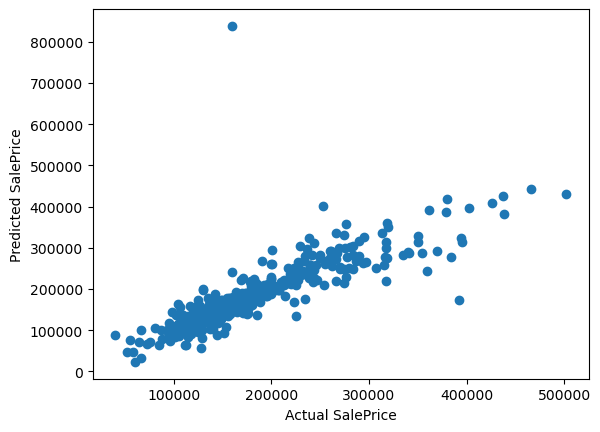

In [59]:
plt.scatter(y_test, y_test_pred)

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.show()

## The behavior of the model with L1 regularization (Lasso) was analyzed. The optimal regularization parameter was selected. Predictions were generated for both the training and test sets, and the model performance was evaluated using MAE, MSE, and $R^2$. The random_state=42 parameter was used to ensure reproducibility

In [60]:
coef = []
for i in range(-4, 5):
    alpha = 10**i
    lasso_regression = Lasso(alpha=alpha, random_state=42
)

    lasso_regression.fit(X_train_processed, y_train)

    coef.append(list(lasso_regression.coef_))

    print('-'*20, 'lambda =', alpha, '-'*20)
    print(lasso_regression.score(X_train_processed, y_train))
    print(lasso_regression.score(X_test_processed, y_test))

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 276628858112.60547, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


-------------------- lambda = 0.0001 --------------------
0.8629532141930902
0.6243996627828152


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 276629711296.6276, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


-------------------- lambda = 0.001 --------------------
0.8629532141910163
0.6244001149229157


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 315182878725.31824, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


...

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 226685175590.62738, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


-------------------- lambda = 1 --------------------
0.8629510081917464
0.6249548256717948


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7853246572.607178, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


-------------------- lambda = 10 --------------------
0.8627817033162337
0.6296917118376735
-------------------- lambda = 100 --------------------
0.8569355887878836
0.6528053060799259
-------------------- lambda = 1000 --------------------
0.8351366193606874
0.6872753392605324
-------------------- lambda = 10000 --------------------
0.7657117411845376
0.6712837802588978


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2843821762.3479004, tolerance: 686041323.2589937
  model = cd_fast.sparse_enet_coordinate_descent(


The best regularization parameter was **α = 1000**. With this value, the **R² score on the test set is approximately 0.687**. When α was further increased to 10,000, the model performance decreased to **0.671**. Therefore, **α = 1000** was the optimal value among the tested parameters.

In [61]:
best_lasso = Lasso(alpha=1000, random_state=42)

In [62]:
best_lasso.fit(X_train_processed, y_train)

Lasso(alpha=1000, random_state=42)

In [63]:
y_train_pred = best_lasso.predict(X_train_processed)
y_test_pred = best_lasso.predict(X_test_processed)

In [64]:
print('TRAIN')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print('R²:', r2_score(y_train, y_train_pred))

print('\nTEST')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('R²:', r2_score(y_test, y_test_pred))

TRAIN
MAE: 20440.79582178396
MSE: 1106683872.903573
R²: 0.8351366193606874

TEST
MAE: 21387.123628955607
MSE: 1674428799.0462806
R²: 0.6872753392605324


In [65]:
print('w0:', best_lasso.intercept_)
print('Number of model weights:', len(best_lasso.coef_))
print('Number of zero-valued weights:', sum(best_lasso.coef_ == 0))
print(f'w1: {best_lasso.coef_}')

w0: 179407.79549682848
Number of model weights: 119
Number of zero-valued weights: 102
w1: [  7310.443684    19025.68841611   5835.06218661   1798.91285266
    672.91597006      0.          11589.33968408      0.
   6671.49519512      0.         -10270.11517755     -0.
  27572.14378877     -0.              0.           1437.56412473
     -0.             -0.             -0.             -0.
     -0.             -0.              0.              0.
     -0.              0.           7969.4466062       0.
     -0.          -3553.7854738      -0.              0.
      0.              0.             -0.             -0.
     -0.            197.40062527      0.             -0.
     -0.              0.              0.             -0.
      0.             -0.              0.           2891.16523737
      0.             -0.             -0.          -1505.73878435
      0.             -0.          38787.6362406       0.
     -0.          -1335.30231157      0.              0.
      0.              

As a result of selecting the regularization parameter, the best value was **α = 1000**, with an **R² score of 0.6873** on the test set. The **MAE** was **21,387.12**, and the **MSE** was **1,674,428,799.05**.

L1 regularization (Lasso) significantly reduced the number of features used by the model: out of **119 weights, 102 became zero**, leaving only **17 non-zero coefficients**. This demonstrates that Lasso performs not only model regularization but also automatic feature selection.

The difference between the model's performance on the training and test sets is relatively small, indicating reduced overfitting.

## The behavior of the model with L2 regularization (Ridge) was analyzed. The optimal regularization parameter was selected. Predictions were generated for both the training and test sets, and model performance was evaluated using MAE, MSE, and $R^2$. The `random_state=42` parameter was used to ensure reproducibility.

In [66]:
coef = []
for i in range(-7, 5):
    alpha = 10**i
    ridge_regression = Ridge(alpha=alpha, random_state=42
)

    ridge_regression.fit(X_train_processed, y_train)

    coef.append(list(ridge_regression.coef_))

    print('-'*20, 'lambda =', alpha, '-'*20)
    print(ridge_regression.score(X_train_processed, y_train))
    print(ridge_regression.score(X_test_processed, y_test))

-------------------- lambda = 1e-07 --------------------
0.8629501229624031
0.6243613837653244
-------------------- lambda = 1e-06 --------------------
0.8629502394768309
0.6243693970275617
-------------------- lambda = 1e-05 --------------------
0.8629502584551367
0.624399349721696
-------------------- lambda = 0.0001 --------------------
0.8629502452795811
0.6243712016289378
-------------------- lambda = 0.001 --------------------
0.8629502464537633
0.6243772099949757
-------------------- lambda = 0.01 --------------------
0.8629501563444151
0.6245483348420003
-------------------- lambda = 0.1 --------------------
0.8629390561499185
0.625733679099072
-------------------- lambda = 1 --------------------
0.8625789759142608
0.6348293640174749
-------------------- lambda = 10 --------------------
0.8579346934094438
0.6678138511384096
-------------------- lambda = 100 --------------------
0.8393094355255443
0.6978214646914354
-------------------- lambda = 1000 --------------------
0.78498

In [67]:
best_ridge = Ridge(alpha=1000, random_state=42)
best_ridge.fit(X_train_processed, y_train)

Ridge(alpha=1000, random_state=42)

In [68]:
y_train_pred = best_ridge.predict(X_train_processed)
y_test_pred = best_ridge.predict(X_test_processed)

In [69]:
print('TRAIN')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print('R²:', r2_score(y_train, y_train_pred))

print('\nTEST')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('R²:', r2_score(y_test, y_test_pred))

TRAIN
MAE: 22365.197444023554
MSE: 1443327583.890823
R²: 0.7849865976397533

TEST
MAE: 21986.377859713153
MSE: 1513299698.947722
R²: 0.71736861237688


In [70]:
print('w0:', best_ridge.intercept_)
print('Number of model weights:', len(best_ridge.coef_))
print('Number of zero-valued weights:', sum(best_ridge.coef_ == 0))
print(f'w1: {best_ridge.coef_}')

w0: 183726.0694688857
Number of model weights: 119
Number of zero-valued weights: 0
w1: [ 5.70948508e+03  1.17322765e+04  2.58722271e+03  3.82121922e+03
  3.05084167e+03  8.82725290e+03  1.18299334e+04  5.31436904e+03
  7.62197115e+03 -4.18232870e+01 -3.81863836e+03 -3.05170943e+03
  1.22684008e+04 -1.28964422e+02  1.28964422e+02  1.72103472e+03
 -3.29584978e+02 -3.83382384e+02 -6.53665083e+02 -3.54402274e+02
 -3.28634284e+01 -2.11320601e+03  7.06610657e+01  2.07577475e+03
 -4.97091898e+01  4.93428125e+01  2.63075373e+03 -1.32380040e+02
  8.23993341e+02 -3.32236703e+03  1.99626453e+01 -1.32471667e+02
  1.34456634e+02 -9.71028064e+00 -1.22373313e+01 -4.10445811e+02
 -1.91890146e+03  2.26760077e+03  1.65187681e+02 -4.03465098e+01
 -6.30946733e+01  2.06826215e+01  1.36477870e+02 -1.63375457e+02
 -1.50123229e+01 -4.23138937e+01  6.35411816e+01  2.46364559e+03
 -5.34203740e+01 -5.78120236e+02 -8.11801244e+00 -1.82398696e+03
 -5.67522462e+02  5.67522462e+02  4.06982980e+03 -2.13068847e+02
 -

For the Ridge regression model, the best regularization parameter was **α = 1000**. On the test set, the model achieved an **R² score of 0.7174**, an **MAE of 21,986.38**, and an **MSE of 1,513,299,698.95**.

After applying L2 regularization, all **119 model coefficients remained non-zero**. Unlike Lasso, Ridge does not perform strict feature selection but instead reduces the magnitude of the coefficients. Therefore, L2 regularization keeps all features in the model while reducing the influence of their coefficients, which helps reduce overfitting.

### Model Comparison

| Model             |   Test R² |
| ----------------- | --------: |
| Linear Regression |     0.624 |
| Lasso             |     0.687 |
| Ridge             | **0.717** |

**Ridge Regression achieved the best result on the test set.**

## Answer the following questions:

### 1. Features with the largest positive coefficients

In the final trained model, the three features with the largest positive coefficients were selected.

Can it be concluded that higher values of these features always lead to a higher sale price?

In [71]:
feature_names = preprocessor.get_feature_names_out()

In [72]:
coef_ridge = pd.Series(best_ridge.coef_, index=feature_names)

In [73]:
top_positive = coef_ridge[coef_ridge > 0].sort_values(ascending=False).head(3)
print(top_positive)

num__TotalLivingArea    12268.400794
num__GrLivArea          11829.933370
num__OverallQual        11732.276507
dtype: float64


All three features have positive coefficients, so an increase in their values is associated with an increase in the predicted house price. However, the final price also depends on other features, so it cannot be concluded that this relationship always holds.

### 2. Features with the largest negative coefficients

In the final trained model, the three features with the largest negative coefficients were selected. Can it be concluded that higher values of these features always lead to a lower sale price?

In [74]:
top_negative = coef_ridge[coef_ridge < 0].sort_values(ascending=True).head(3)
print(top_negative)

num__HouseAge         -3818.638364
cat__ExterQual_TA     -3322.367032
cat__KitchenQual_TA   -3103.416577
dtype: float64


The three features with the largest negative coefficients are **HouseAge**, **ExterQual_TA**, and **KitchenQual_TA**.

Negative coefficients indicate that these features are associated with a decrease in the predicted house price. For **HouseAge**, this means that older houses tend to have lower predicted prices. For the categorical features **ExterQual_TA** and **KitchenQual_TA**, this means that belonging to these categories is associated with a lower predicted house price.

### 3. Features with Zero Coefficients in the Lasso Model

Three features with zero coefficients were selected in the Lasso model. Possible reasons for their exclusion can be considered. Can it be confidently concluded that the sale price does not depend on these features?

In [75]:
coef_lasso = pd.Series(best_lasso.coef_, index=feature_names)

In [76]:
zero_coef = coef_lasso[coef_lasso == 0].head(3)
print(zero_coef)

num__TotalBsmtSF    0.0
num__Bath           0.0
num__YearSold       0.0
dtype: float64


Lasso set the coefficients of some features to zero. For example, **TotalBsmtSF**, **Bath**, and **YearSold** have coefficients equal to 0. This means that Lasso excluded these features from the model because they did not provide additional predictive value in this particular model.